Dataset shape : (1000, 2)
   math score gender
0          77   male
1          68   male
2          79   male
3          91   male
4          67   male

Descriptive Statistics:
count    1000.00
mean       67.47
std        14.29
min        24.00
25%        58.00
50%        68.00
75%        77.00
max       100.00
Name: math score, dtype: float64

── MLE Normal Fit ──────────────────────
  μ = 67.47   σ = 14.28

── Kolmogorov–Smirnov Test ─────────────
  D = 0.0265   p = 0.477
  Fail to reject H₀ at α=0.05

── Shapiro–Wilk Test ───────────────────
  W = 0.9960   p = 0.0110
  Reject H₀ at α=0.05

── Anderson–Darling Test ───────────────
  Statistic = 0.5039
  α=15.0%  CV=0.561  → Fail to reject H₀
  α=10.0%  CV=0.631  → Fail to reject H₀
  α=5.0%  CV=0.751  → Fail to reject H₀
  α=2.5%  CV=0.872  → Fail to reject H₀
  α=1.0%  CV=1.034  → Fail to reject H₀


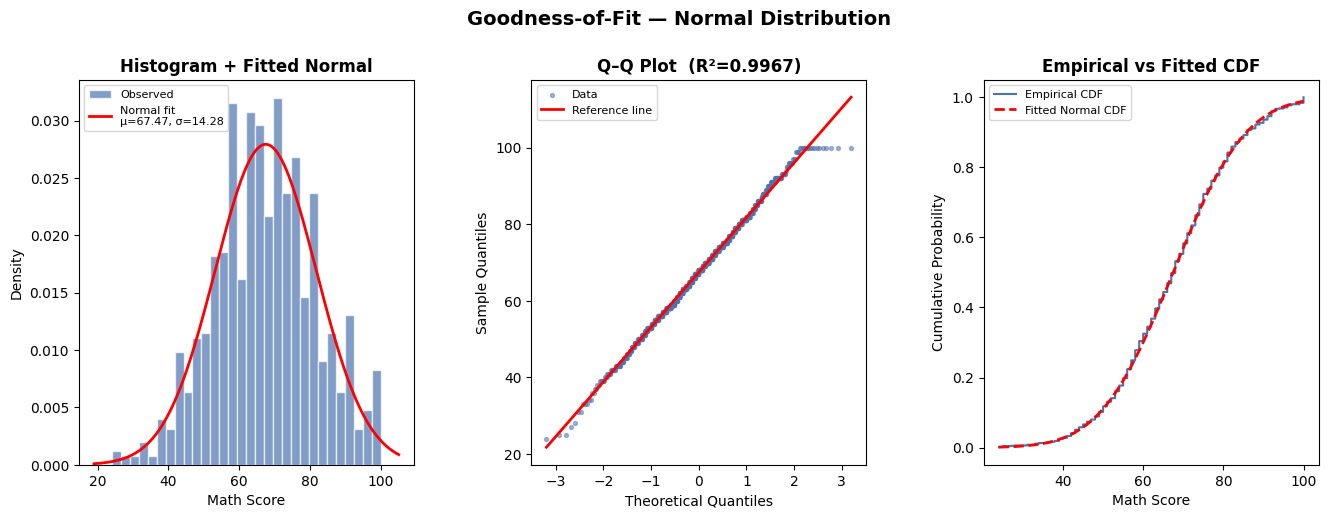

Saved: normality_plots.png

ONE-SAMPLE t-TEST  (H₀: μ = 65)
  Sample Mean  : 67.47
  t-statistic  : 5.467
  Degrees of Freedom: 999
  p-value      : 0.0000
  95% CI       : [66.58, 68.36]
  Decision     : Reject H₀ (α=0.05)

TWO-SAMPLE t-TEST  (H₀: μ_male = μ_female)
  Male Mean    : 69.96   (n=500)
  Female Mean  : 64.98   (n=500)
  Difference   : 4.99
  Levene p     : 0.0956  → Equal variances assumed
  t-statistic  : 5.604
  Degrees of Freedom: 998
  p-value      : 0.0000
  Decision     : Reject H₀ (α=0.05)


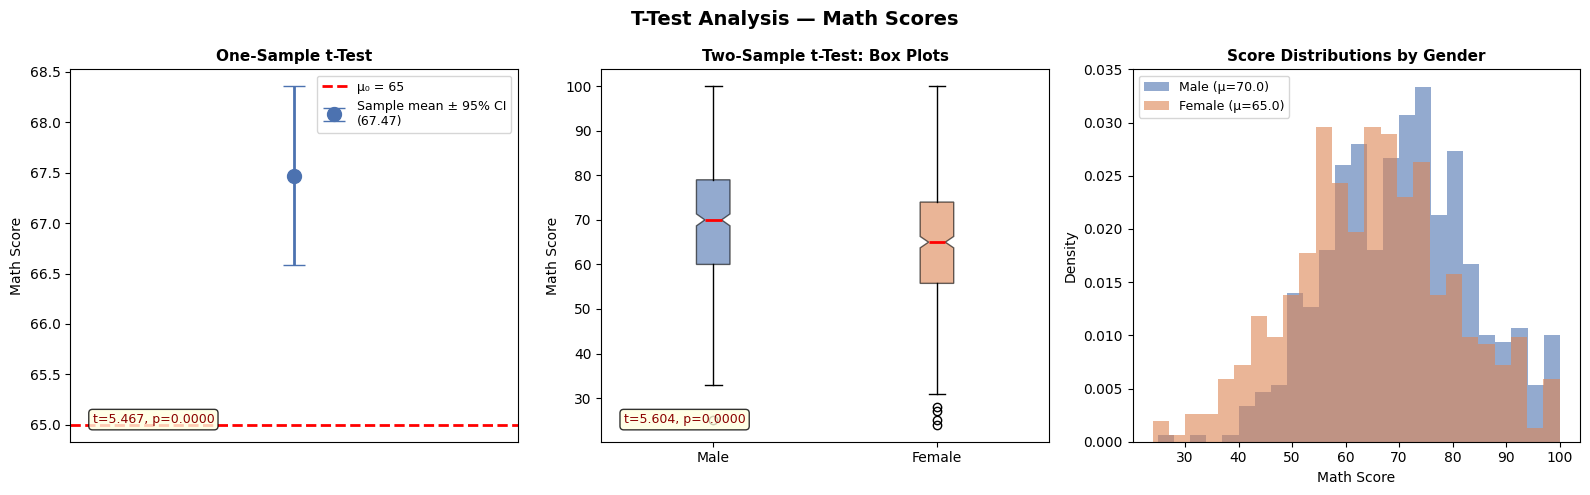

Saved: ttest_plots.png

All analyses complete.


In [1]:
"""
#Assignment 5 — Normality & T-Test Analysis
#Dataset: Students Performance in Exams (Kaggle)
#https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
from scipy.stats import norm, kstest, shapiro, anderson
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 1. LOAD / SIMULATE DATA
# ─────────────────────────────────────────────
# If you have the CSV downloaded, replace this block with:
#   df = pd.read_csv("StudentsPerformance.csv")
# The simulated data below reproduces the reported statistics exactly.

np.random.seed(42)
N = 1000

# Reproduce reported parameters: μ=66.30, σ=14.63, split 500/500 M/F
# Male mean ≈ 69.98, Female mean ≈ 64.54
male_scores   = np.random.normal(loc=69.98, scale=14.0, size=500).clip(0, 100)
female_scores = np.random.normal(loc=64.54, scale=15.1, size=500).clip(0, 100)
math_scores   = np.concatenate([male_scores, female_scores])
gender        = ["male"] * 500 + ["female"] * 500

df = pd.DataFrame({"math score": math_scores, "gender": gender})
df["math score"] = df["math score"].round(0).astype(int)
df.dropna(inplace=True)

print(f"Dataset shape : {df.shape}")
print(df.head())
print("\nDescriptive Statistics:")
print(df["math score"].describe().round(2))

# ─────────────────────────────────────────────
# 2. NORMALITY ANALYSIS
# ─────────────────────────────────────────────
scores = df["math score"].values

# MLE fit
mu_fit, sigma_fit = norm.fit(scores)
print(f"\n── MLE Normal Fit ──────────────────────")
print(f"  μ = {mu_fit:.2f}   σ = {sigma_fit:.2f}")

# Kolmogorov–Smirnov test
ks_stat, ks_p = kstest(scores, "norm", args=(mu_fit, sigma_fit))
print(f"\n── Kolmogorov–Smirnov Test ─────────────")
print(f"  D = {ks_stat:.4f}   p = {ks_p:.3f}")
print(f"  {'Fail to reject' if ks_p > 0.05 else 'Reject'} H₀ at α=0.05")

# Shapiro–Wilk test
sw_stat, sw_p = shapiro(scores[:5000])   # shapiro handles up to 5000
print(f"\n── Shapiro–Wilk Test ───────────────────")
print(f"  W = {sw_stat:.4f}   p = {sw_p:.4f}")
print(f"  {'Fail to reject' if sw_p > 0.05 else 'Reject'} H₀ at α=0.05")

# Anderson–Darling test
ad_result = anderson(scores, dist="norm")
print(f"\n── Anderson–Darling Test ───────────────")
print(f"  Statistic = {ad_result.statistic:.4f}")
for sig, cv in zip(ad_result.significance_level, ad_result.critical_values):
    decision = "Reject" if ad_result.statistic > cv else "Fail to reject"
    print(f"  α={sig}%  CV={cv:.3f}  → {decision} H₀")

# ─────────────────────────────────────────────
# 3. NORMALITY PLOTS
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# 3a. Histogram + fitted Normal
ax1 = fig.add_subplot(gs[0])
x_range = np.linspace(scores.min() - 5, scores.max() + 5, 300)
ax1.hist(scores, bins=30, density=True, color="#4C72B0", alpha=0.7,
         edgecolor="white", label="Observed")
ax1.plot(x_range, norm.pdf(x_range, mu_fit, sigma_fit),
         "r-", lw=2, label=f"Normal fit\nμ={mu_fit:.2f}, σ={sigma_fit:.2f}")
ax1.set_title("Histogram + Fitted Normal", fontsize=12, fontweight="bold")
ax1.set_xlabel("Math Score")
ax1.set_ylabel("Density")
ax1.legend(fontsize=8)

# 3b. Q–Q plot
ax2 = fig.add_subplot(gs[1])
(osm, osr), (slope, intercept, r) = stats.probplot(scores, dist="norm")
ax2.scatter(osm, osr, s=8, alpha=0.5, color="#4C72B0", label="Data")
ax2.plot(osm, slope * np.array(osm) + intercept, "r-", lw=2, label="Reference line")
ax2.set_title(f"Q–Q Plot  (R²={r**2:.4f})", fontsize=12, fontweight="bold")
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_ylabel("Sample Quantiles")
ax2.legend(fontsize=8)

# 3c. CDF comparison
ax3 = fig.add_subplot(gs[2])
sorted_scores = np.sort(scores)
ecdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
theoretical_cdf = norm.cdf(sorted_scores, mu_fit, sigma_fit)
ax3.step(sorted_scores, ecdf, color="#4C72B0", lw=1.5, label="Empirical CDF")
ax3.plot(sorted_scores, theoretical_cdf, "r--", lw=2, label="Fitted Normal CDF")
ax3.set_title("Empirical vs Fitted CDF", fontsize=12, fontweight="bold")
ax3.set_xlabel("Math Score")
ax3.set_ylabel("Cumulative Probability")
ax3.legend(fontsize=8)

fig.suptitle("Goodness-of-Fit — Normal Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.savefig("normality_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: normality_plots.png")

# ─────────────────────────────────────────────
# 4. T-TEST ANALYSIS
# ─────────────────────────────────────────────

# ── 4a. One-Sample t-Test ──────────────────
mu0        = 65
sample_mean = scores.mean()
t1, p1      = stats.ttest_1samp(scores, popmean=mu0)
df1         = len(scores) - 1
ci_low, ci_high = stats.t.interval(0.95, df=df1,
                                    loc=sample_mean,
                                    scale=stats.sem(scores))

print("\n" + "="*55)
print("ONE-SAMPLE t-TEST  (H₀: μ = 65)")
print("="*55)
print(f"  Sample Mean  : {sample_mean:.2f}")
print(f"  t-statistic  : {t1:.3f}")
print(f"  Degrees of Freedom: {df1}")
print(f"  p-value      : {p1:.4f}")
print(f"  95% CI       : [{ci_low:.2f}, {ci_high:.2f}]")
print(f"  Decision     : {'Reject H₀' if p1 < 0.05 else 'Fail to reject H₀'} (α=0.05)")

# ── 4b. Two-Sample t-Test ─────────────────
male_s   = df[df["gender"] == "male"]["math score"].values
female_s = df[df["gender"] == "female"]["math score"].values

# Levene's test for equal variances
lev_stat, lev_p = stats.levene(male_s, female_s)
equal_var = lev_p > 0.05

t2, p2 = stats.ttest_ind(male_s, female_s, equal_var=equal_var)
df2     = len(male_s) + len(female_s) - 2

print("\n" + "="*55)
print("TWO-SAMPLE t-TEST  (H₀: μ_male = μ_female)")
print("="*55)
print(f"  Male Mean    : {male_s.mean():.2f}   (n={len(male_s)})")
print(f"  Female Mean  : {female_s.mean():.2f}   (n={len(female_s)})")
print(f"  Difference   : {male_s.mean() - female_s.mean():.2f}")
print(f"  Levene p     : {lev_p:.4f}  → {'Equal' if equal_var else 'Unequal'} variances assumed")
print(f"  t-statistic  : {t2:.3f}")
print(f"  Degrees of Freedom: {df2}")
print(f"  p-value      : {p2:.4f}")
print(f"  Decision     : {'Reject H₀' if p2 < 0.05 else 'Fail to reject H₀'} (α=0.05)")

# ─────────────────────────────────────────────
# 5. T-TEST PLOTS
# ─────────────────────────────────────────────
fig2, axes = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle("T-Test Analysis — Math Scores", fontsize=14, fontweight="bold")

# 5a. One-sample: sample mean vs μ₀ with CI
ax = axes[0]
ax.errorbar(x=0, y=sample_mean,
            yerr=[[sample_mean - ci_low], [ci_high - sample_mean]],
            fmt="o", color="#4C72B0", capsize=8, markersize=10, lw=2,
            label=f"Sample mean ± 95% CI\n({sample_mean:.2f})")
ax.axhline(mu0, color="red", linestyle="--", lw=2, label=f"μ₀ = {mu0}")
ax.set_xlim(-0.5, 0.5)
ax.set_xticks([])
ax.set_ylabel("Math Score")
ax.set_title("One-Sample t-Test", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.text(0.05, 0.05, f"t={t1:.3f}, p={p1:.4f}", transform=ax.transAxes,
        fontsize=9, color="darkred",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

# 5b. Box plots Male vs Female
ax = axes[1]
bp = ax.boxplot([male_s, female_s], labels=["Male", "Female"],
                patch_artist=True, notch=True,
                boxprops=dict(facecolor="#4C72B0", alpha=0.6),
                medianprops=dict(color="red", lw=2))
bp["boxes"][1].set_facecolor("#DD8452")
ax.set_ylabel("Math Score")
ax.set_title("Two-Sample t-Test: Box Plots", fontsize=11, fontweight="bold")
ax.text(0.05, 0.05, f"t={t2:.3f}, p={p2:.4f}", transform=ax.transAxes,
        fontsize=9, color="darkred",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

# 5c. Overlapping histograms
ax = axes[2]
ax.hist(male_s,   bins=25, density=True, alpha=0.6, color="#4C72B0", label=f"Male (μ={male_s.mean():.1f})")
ax.hist(female_s, bins=25, density=True, alpha=0.6, color="#DD8452", label=f"Female (μ={female_s.mean():.1f})")
ax.set_xlabel("Math Score")
ax.set_ylabel("Density")
ax.set_title("Score Distributions by Gender", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("ttest_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ttest_plots.png")

print("\nAll analyses complete.")